**Problem Statement:** <br>
Implement Simple and Multiple Linear Regression to predict continuous variables.
1. Perform data preprocessing (handle missing values, feature scaling).
2. Fit a Simple Linear Regression model on a dataset (e.g., predicting house prices).
3. Extend to Multiple Linear Regression with multiple features.
4. Evaluate models using MSE, RMSE, and R² Score.
5. Visualize the regression line and predictions.

# Import necessary libraries and dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset

In [2]:
california = fetch_california_housing(as_frame=True)
df = california.frame

# Display first few rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Data preprocessing

## Check for null values

In [3]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


## Feature Scaling

In [4]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Simple Linear Regression

## Prepare data

In [5]:
X_simple = df[["MedInc"]]
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

## Train model

In [6]:
simple_lr = LinearRegression()
simple_lr.fit(X_train, y_train)

LinearRegression()

## Predictions and Evaluation

In [7]:
y_pred_simple = simple_lr.predict(X_test)

mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print("Simple Linear Regression")
print("MSE:", mse_simple)
print("RMSE:", rmse_simple)
print("R² Score:", r2_simple)

Simple Linear Regression
MSE: 0.7091157771765549
RMSE: 0.8420901241414455
R² Score: 0.45885918903846656


## Visualization line (Regression)

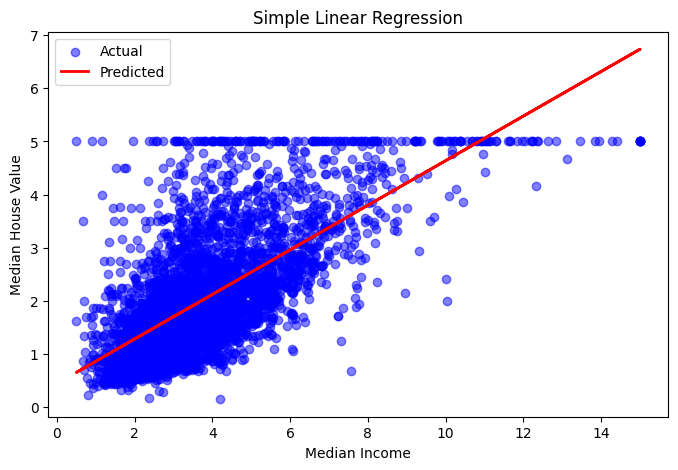

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, color="blue", alpha=0.5, label="Actual")
plt.plot(X_test, y_pred_simple, color="red", linewidth=2, label="Predicted")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

# Multiple Linear Regression

# Train, Test, Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## Train model

In [10]:
multi_lr = LinearRegression()
multi_lr.fit(X_train, y_train)

LinearRegression()

## Predictions and Evaluation

In [11]:
y_pred_multi = multi_lr.predict(X_test)

mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("Multiple Linear Regression")
print("MSE:", mse_multi)
print("RMSE:", rmse_multi)
print("R² Score:", r2_multi)

Multiple Linear Regression
MSE: 0.555891598695244
RMSE: 0.7455813830127761
R² Score: 0.5757877060324511


# Visualization (Actual vs Predicted)

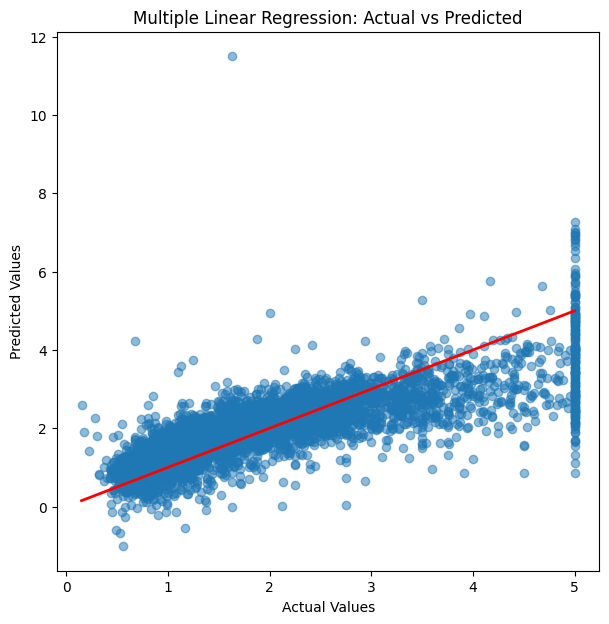

In [12]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_multi, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.show()

# Final Comparison

In [13]:
results = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
    "MSE": [mse_simple, mse_multi],
    "RMSE": [rmse_simple, rmse_multi],
    "R² Score": [r2_simple, r2_multi]
})

results

,Model,MSE,RMSE,R² Score
0,Simple Linear Regression,0.709116,0.842090,0.458859
1,Multiple Linear Regression,0.555892,0.745581,0.575788
